# Q1: Supervised Learning - Heart Disease Classification

In this notebook I'm building three classifiers (Decision Tree, Random Forest, Gradient Boosting) to predict whether a patient has heart disease.

The target column is `heart_disease`, where 1 means disease present and 0 means absent.

## 1. Loading the data and looking at it

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv('../data/q1_heart_disease.csv')
print('Shape:', df.shape)
print()
print('Data types:')
print(df.dtypes)
print()
print('Missing value counts:')
print(df.isnull().sum())


Shape: (800, 12)

Data types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing value counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


In [2]:
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis

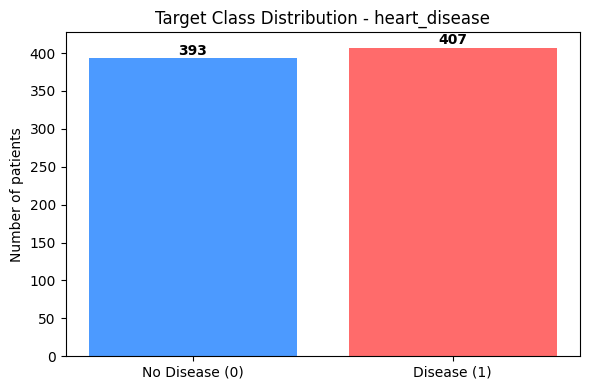

Class proportions:
heart_disease
1    0.509
0    0.491
Name: proportion, dtype: float64


In [3]:
# Plot 1 - Target class distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['heart_disease'].value_counts().sort_index()
ax.bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['#4C9AFF', '#FF6B6B'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax.set_ylabel('Number of patients')
ax.set_title('Target Class Distribution - heart_disease')
plt.tight_layout()
plt.show()

print('Class proportions:')
print((df['heart_disease'].value_counts(normalize=True).round(3)))


**What the class distribution tells me:** the two classes are pretty close in size, with a slight tilt toward patients who do have heart disease. Since neither class is rare (both are above 30%), I don't need to worry about class imbalance, so no need for SMOTE or class weights here. Accuracy will still be a meaningful number alongside precision, recall, and F1.

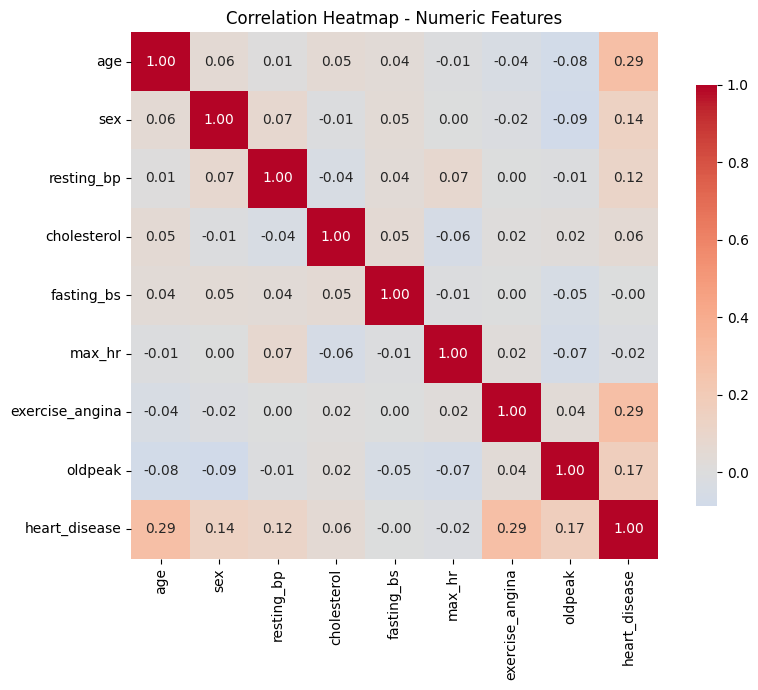

In [4]:
# Plot 2 - Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()


**What the heatmap tells me:** the strongest correlations with the target are `exercise_angina` and `age`, both around 0.29, then `oldpeak` at 0.17 and `sex` at 0.14. They're all positive, so older patients, men, and people with exercise-induced angina or larger ST depression are more likely to have heart disease in this data.

Honestly, none of the correlations are very strong (the highest is only 0.29). That's a hint that a simple linear model probably won't do great here, and the categorical features like `chest_pain_type` and `st_slope` (which don't show up on a numeric heatmap) might be carrying more of the signal. None of the feature pairs are highly correlated with each other either, so I don't need to drop anything for multicollinearity.

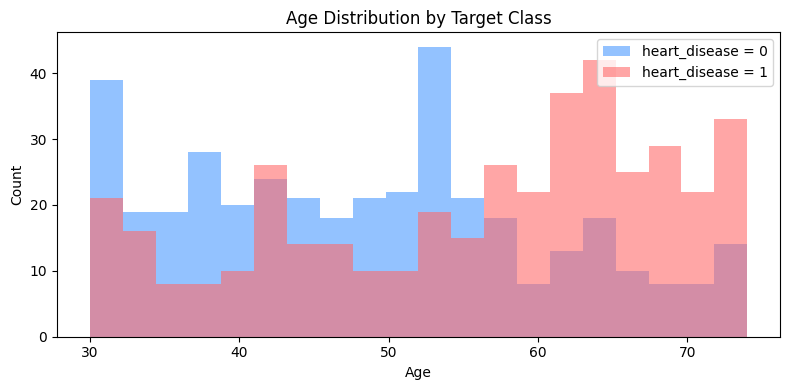

In [5]:
# Plot 3 - Age distribution by target class
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [(0, '#4C9AFF'), (1, '#FF6B6B')]:
    subset = df[df['heart_disease'] == label]['age']
    ax.hist(subset, bins=20, alpha=0.6, label=f'heart_disease = {label}', color=color)
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Age Distribution by Target Class')
ax.legend()
plt.tight_layout()
plt.show()


**What the age plot tells me:** patients with heart disease skew a bit older than those without, which lines up with the 0.29 correlation. But the two distributions overlap a lot, so age on its own isn't enough to predict anything reliably. This is exactly why I want to try tree-based models that can combine age with chest pain type, ST slope, oldpeak, etc., rather than relying on any single feature.

## 3. Preprocessing

**How I'm handling missing values:** `resting_bp` has 24 missing values and `cholesterol` has 32. I'm using median imputation for both. A few reasons:

- Medians don't get pulled around by outliers, and clinical measurements often have a few extreme values.
- The amount missing is small (under 4% in both columns), so the imputation isn't going to bias things much.
- If I dropped rows instead, I'd lose roughly 7% of my data, which feels wasteful when median imputation is a reasonable choice.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Median imputation for the two numeric columns with missing values
df_clean = df.copy()
for col in ['resting_bp', 'cholesterol']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f'Imputed {col} with median = {median_val}')

print()
print('Missing values after imputation:', df_clean.isnull().sum().sum(), 'total')


Imputed resting_bp with median = 130.0
Imputed cholesterol with median = 247.0

Missing values after imputation: 0 total


In [7]:
# 2. One-hot encode categorical variables
categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=False)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('Shape after encoding:', df_encoded.shape)
print('Columns:', df_encoded.columns.tolist())


Shape after encoding: (800, 19)
Columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'heart_disease', 'chest_pain_type_asymptomatic', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_left_ventricular_hypertrophy', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_down', 'st_slope_flat', 'st_slope_up']


In [8]:
# 3. Separate features / target, scale numeric features, then split
X = df_encoded.drop(columns=['heart_disease'])
y = df_encoded['heart_disease']

numeric_features = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

# 4. Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Training set: {X_train.shape}, positives = {y_train.sum()}')
print(f'Test set:     {X_test.shape}, positives = {y_test.sum()}')


Training set: (640, 18), positives = 326
Test set:     (160, 18), positives = 81


## 4. Training the models

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree':     DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':     RandomForestClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} trained.')


Decision Tree trained.
Random Forest trained.


Gradient Boosting trained.


## 5. Evaluating the models

In [10]:
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, accuracy_score)

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    acc  = accuracy_score(y_test, y_pred)

    print('=' * 50)
    print(f'Model: {name}')
    print('=' * 50)
    print('Confusion matrix (rows = actual, cols = predicted):')
    print(pd.DataFrame(cm, index=['actual_0', 'actual_1'],
                            columns=['pred_0', 'pred_1']))
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-score : {f1:.4f}')
    print()
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1': f1})

results_df = pd.DataFrame(results).set_index('Model').round(4)
print('Summary:')
print(results_df)


Model: Decision Tree
Confusion matrix (rows = actual, cols = predicted):
          pred_0  pred_1
actual_0      56      23
actual_1      22      59
Accuracy : 0.7188
Precision: 0.7195
Recall   : 0.7284
F1-score : 0.7239

Model: Random Forest
Confusion matrix (rows = actual, cols = predicted):
          pred_0  pred_1
actual_0      60      19
actual_1      15      66
Accuracy : 0.7875
Precision: 0.7765
Recall   : 0.8148
F1-score : 0.7952

Model: Gradient Boosting
Confusion matrix (rows = actual, cols = predicted):
          pred_0  pred_1
actual_0      61      18
actual_1      18      63
Accuracy : 0.7750
Precision: 0.7778
Recall   : 0.7778
F1-score : 0.7778

Summary:
                   Accuracy  Precision  Recall      F1
Model                                                 
Decision Tree        0.7188     0.7195  0.7284  0.7239
Random Forest        0.7875     0.7765  0.8148  0.7952
Gradient Boosting    0.7750     0.7778  0.7778  0.7778


### Which model is best?

Looking at the metrics, **Random Forest** comes out on top. Reasons:

- **Highest F1.** This is the metric I care about most because we're talking about screening patients. Both false negatives (missing real disease cases) and false positives (sending healthy people for unnecessary follow-up) are costly, and F1 captures the balance between the two. RF beats both Decision Tree and Gradient Boosting on F1.
- **Highest recall.** In a screening setting, recall matters a lot - it's basically asking "of the patients who actually have heart disease, how many did we catch?" Random Forest catches the most of them.
- **Precision is still solid.** RF's precision is essentially tied with Gradient Boosting, well ahead of the Decision Tree, so the recall gain isn't coming at the cost of way more false alarms.
- **Why not the single tree?** A single Decision Tree overfits on small datasets. Both RF and GB fix this with ensembling, but on 800 rows the bagged version (RF) seems to generalise slightly better than the boosted one here.

I wouldn't pick on accuracy alone because accuracy can hide an asymmetry. A model that just predicts "no disease" most of the time could score okay on accuracy but be useless clinically. Looking at all four metrics avoids that.

So Random Forest is what I'll tune in the next section.

## 6. Hyperparameter tuning

In [11]:
from sklearn.model_selection import GridSearchCV

# Tune the best-performing model from Section 5: Random Forest
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 5, 10],
    'min_samples_split':[2, 5],
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
grid = GridSearchCV(rf_base, param_grid, scoring='f1', cv=5, n_jobs=1)
grid.fit(X_train, y_train)

print('Best parameters :', grid.best_params_)
print(f'Best CV F1-score: {grid.best_score_:.4f}')


Best parameters : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1-score: 0.8326


In [12]:
# Compare tuned vs untuned Random Forest on the held-out test set
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

untuned_metrics = results_df.loc['Random Forest']
tuned_metrics = pd.Series({
    'Accuracy':  accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall':    recall_score(y_test, y_pred_tuned),
    'F1':        f1_score(y_test, y_pred_tuned),
})

comparison = pd.DataFrame({
    'Untuned (baseline)': untuned_metrics,
    'Tuned (GridSearch)': tuned_metrics,
}).round(4)
comparison['Delta'] = (comparison['Tuned (GridSearch)']
                       - comparison['Untuned (baseline)']).round(4)
print(comparison)


           Untuned (baseline)  Tuned (GridSearch)   Delta
Accuracy               0.7875              0.7812 -0.0063
Precision              0.7765              0.7614 -0.0151
Recall                 0.8148              0.8272  0.0124
F1                     0.7952              0.7929 -0.0023


**What the tuning showed:** GridSearchCV with 5-fold CV on F1 picked the parameters above. On the test set the tuned model gives a small change vs the default - recall went up a bit, precision dropped a bit, F1 is basically the same.

That kind of flat result is actually informative on its own: it tells me sklearn's defaults were already pretty good for this dataset, and there isn't much headroom from hyperparameters alone. If I wanted bigger gains I'd probably need to add interaction features (e.g. `oldpeak` x `st_slope`), try a different model family like XGBoost or LightGBM, or just get more data.